# ```sampley``` exemplar: the segment approach with continuous datapoints
Before going through this exemplar, please consult the _Introduction to sampley exemplars_ (```intro.ipynb```).
<br>This exemplar illustrates an application of the segment approach to data contained within a single file (```trackpoints.csv```) that contains continuous datapoints (i.e., datapoints recorded at frequent, regular intervals) that can be joined to construct survey tracks.
<br>It differs from the standard segment exemplar as having continuous datapoints allows for certain procedures to be applied in Stage 3 that may be more efficient and precise.

## Setup

### Import the package

In [1]:
from sampley import *

### Set the import folder
To run this exemplar, download the mock data files, put them in a folder, and set the path to the folder below.

In [2]:
import_folder = './import/'

### Set the export folder
To run this exemplar, make a folder to save the samples in and set the path to the folder below.

In [3]:
export_folder = './export/'

## Stage 1
In Stage 1, we import a single file (```trackpoints.csv```) to make a ```DataPoints``` object, from which we then make a ```Sections``` object.
<br>Although we use a CSV file in this exemplar, there are other options for file types (including XLSX, GPKG, and SHP files). Please see the Stage 1 exemplar (```stage-1.ipynb```) in the horizontal exemplars folder or the User Manual for more details. Note that, regardless of the imported file type, once any ```DataPoints``` and/or ```Sections``` objects have been made, the subsequent processing will be the same.

In [4]:
u_trackpoints = DataPoints.from_file(
    filepath=import_folder+'trackpoints.csv',
    x_col='lon',
    y_col='lat',
    crs_import='EPSG:4326',
    crs_working='EPSG:32619',
    datetime_col='datetime',
    tz_import='UTC-05:00',
    section_id_col='section_id'  
)

Success: file opened.
Success: X and Y coordinates parsed.
Success: reprojected to CRS "EPSG:32619"
Success: column "datetime" reformatted to datetimes.
Success: timezone of column "datetime" set to "UTC-05:00".
Success: datapoint IDs generated.


In [5]:
u_sections = Sections.from_datapoints(datapoints=u_trackpoints)

## Stage 2
In Stage 2, we use the ```Sections``` object to make a ```Segments``` object containing segments with a target length of 10000 m. Here, we use the redistribution variation. To use a different variation, we could simply replace ```'redistribution'``` with ```'joining'``` or ```'simple'```.

In [6]:
u_segments = Segments.delimit(
    sections=u_sections,
    var='redistribution',  # replace 'redistribution' with 'joining' or 'simple' for the joining or simple variations, respectively
    target=10000)

Additionally, we can use the ```datetimes``` method, along with our ```DataPoints``` object, to get a begin, middle, and end datetime for each segment.

In [7]:
u_segments.datetimes(datapoints=u_trackpoints)

In [8]:
u_segments.segments  # print the segments GeoDataFrame

,segment_id,line,midpoint,date,datetime_beg,datetime_mid,datetime_end,section_id,dfbsec_beg,dfbsec_end
0,s01-r10000m,"LINESTRING (580092.757 4742883.408, 579997.135...",POINT (575093.021 4742845.959),2019-01-25,2019-01-25 10:18:13-05:00,2019-01-25 10:19:55-05:00,2019-01-25 10:21:38-05:00,s001,0.000000,10000.580283
1,s02-r10000m,"LINESTRING (570093.642 4742829.91, 569917.081 ...",POINT (565093.86 4742799.716),2019-01-25,2019-01-25 10:21:38-05:00,2019-01-25 10:23:17-05:00,2019-01-25 10:24:57-05:00,s001,10000.580283,20001.160565
2,s03-r10000m,"LINESTRING (560093.988 4742773.153, 559864.339...",POINT (555094.071 4742749.107),2019-01-25,2019-01-25 10:24:57-05:00,2019-01-25 10:26:37-05:00,2019-01-25 10:28:17-05:00,s001,20001.160565,30001.740848
3,s04-r10000m,"LINESTRING (550093.926 4742710.923, 549838.842...",POINT (545093.756 4742676.369),2019-01-25,2019-01-25 10:28:17-05:00,2019-01-25 10:29:56-05:00,2019-01-25 10:31:35-05:00,s001,30001.740848,40002.321130
4,s05-r10000m,"LINESTRING (540093.561 4742645.442, 539704.822...",POINT (535094.224 4742648.431),2019-01-25,2019-01-25 10:31:35-05:00,2019-01-25 10:33:14-05:00,2019-01-25 10:34:53-05:00,s001,40002.321130,50002.901413
...,...,...,...,...,...,...,...,...,...,...
64,s65-r10000m,"LINESTRING (652980.044 4697677.144, 652979.945...",POINT (647917.17 4697623.667),2019-03-05,2019-03-05 12:51:07-05:00,2019-03-05 12:52:58-05:00,2019-03-05 12:54:50-05:00,s004,273463.867857,283592.159259
65,s66-r10000m,"LINESTRING (642854.209 4697537.196, 642721.486...",POINT (637791.127 4697454.392),2019-03-05,2019-03-05 12:54:50-05:00,2019-03-05 12:56:39-05:00,2019-03-05 12:58:29-05:00,s004,283592.159259,293720.450662
66,s67-r10000m,"LINESTRING (632727.93 4697356.37, 632683.219 4...",POINT (627664.663 4697262.02),2019-03-05,2019-03-05 12:58:29-05:00,2019-03-05 13:00:21-05:00,2019-03-05 13:02:14-05:00,s004,293720.450662,303848.742064
67,s68-r10000m,"LINESTRING (622602.172 4697152.471, 622357.753...",POINT (617538.774 4697065.46),2019-03-05,2019-03-05 13:02:14-05:00,2019-03-05 13:04:07-05:00,2019-03-05 13:06:00-05:00,s004,303848.742064,313977.033466


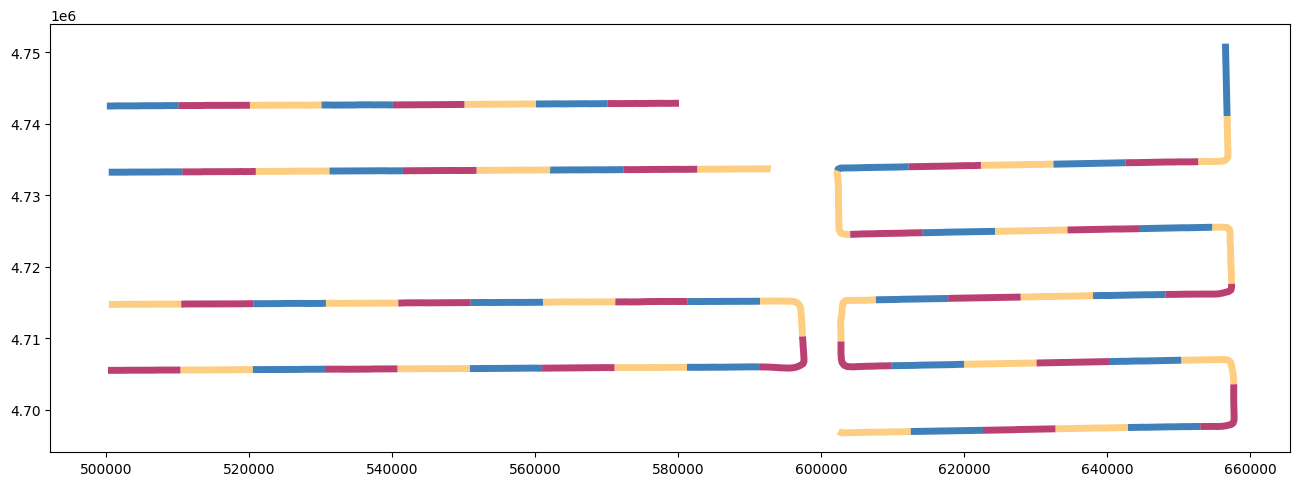

In [9]:
u_segments.plot()  # plot the segments

## Stage 3
In Stage 3, we, firstly, make two ```Samples``` objects:
- one from the ```DataPoints``` object containing sightings and environmental data and the ```Segments``` object
- one from the ```Segments``` object

_Note that, as the segments are made from sections that are made from datapoints, we can match those datapoints to the segments by their distance from the beginning of the section (```how='dfb'```), rather than by absolute distance to the midpoint or line. This is more accurate and faster._
<br>Then, we merge these two ```Samples``` objects to make our final ```Samples``` object.

In [10]:
u_samples_trackpoints = Samples.segment(
    datapoints=u_trackpoints,
    segments=u_segments,
    cols={'individuals': 'sum', 'bss': 'mean'},
    how='dfb')

In [11]:
u_samples_effort = Samples.segment_se(segments=u_segments)

In [12]:
u_samples = Samples.merge(
    trackpoints=u_samples_trackpoints,
    effort=u_samples_effort)

Note: samples generated with the segment approach


## Export
Finally, we save the final ```Samples``` object to the export folder.

In [13]:
u_samples.save(
    folder=export_folder,
    filetype='csv',
    crs_export='EPSG:4326'
)

Success: additional geometry column "midpoint" reprojected to CRS "EPSG:4326"
Success: reprojected to CRS "EPSG:4326"


In the export folder, there should be two new CSVs: the first should have the same name as the ```Samples``` object (run the box below to see the name) while the second should also have this name but with ```-parameters``` added at the end.

In [14]:
u_samples.name

'samples-trackpoints+effort-x-segments-r10000m'

The first CSV should contain the samples, like those shown in the box below. 
<br>In this dataframe, each row represents a given segment, i.e., a sample. 
<br>The column ```line``` delimits the extent of the segment, while the column ```midpoint``` represents the centre of the segment.
<br>At the end are the data columns. In this particular example, they are ```individuals```, ```bss```, and ```se_length```.

In [15]:
u_samples.samples

,segment_id,line,midpoint,date,datetime_beg,datetime_mid,datetime_end,section_id,dfbsec_beg,dfbsec_end,individuals,bss,se_length
0,s01-r10000m,"LINESTRING (580092.757 4742883.408, 579997.135...",POINT (575093.021 4742845.959),2019-01-25,2019-01-25 10:18:13-05:00,2019-01-25 10:19:55-05:00,2019-01-25 10:21:38-05:00,s001,0.000000,10000.580283,1.0,2.000000,10000.580283
1,s02-r10000m,"LINESTRING (570093.642 4742829.91, 569917.081 ...",POINT (565093.86 4742799.716),2019-01-25,2019-01-25 10:21:38-05:00,2019-01-25 10:23:17-05:00,2019-01-25 10:24:57-05:00,s001,10000.580283,20001.160565,0.0,2.000000,10000.580283
2,s03-r10000m,"LINESTRING (560093.988 4742773.153, 559864.339...",POINT (555094.071 4742749.107),2019-01-25,2019-01-25 10:24:57-05:00,2019-01-25 10:26:37-05:00,2019-01-25 10:28:17-05:00,s001,20001.160565,30001.740848,2.0,2.000000,10000.580283
3,s04-r10000m,"LINESTRING (550093.926 4742710.923, 549838.842...",POINT (545093.756 4742676.369),2019-01-25,2019-01-25 10:28:17-05:00,2019-01-25 10:29:56-05:00,2019-01-25 10:31:35-05:00,s001,30001.740848,40002.321130,5.0,2.846154,10000.580283
4,s05-r10000m,"LINESTRING (540093.561 4742645.442, 539704.822...",POINT (535094.224 4742648.431),2019-01-25,2019-01-25 10:31:35-05:00,2019-01-25 10:33:14-05:00,2019-01-25 10:34:53-05:00,s001,40002.321130,50002.901413,0.0,3.000000,10000.580283
...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,s65-r10000m,"LINESTRING (652980.044 4697677.144, 652979.945...",POINT (647917.17 4697623.667),2019-03-05,2019-03-05 12:51:07-05:00,2019-03-05 12:52:58-05:00,2019-03-05 12:54:50-05:00,s004,273463.867857,283592.159259,0.0,2.000000,10128.291402
65,s66-r10000m,"LINESTRING (642854.209 4697537.196, 642721.486...",POINT (637791.127 4697454.392),2019-03-05,2019-03-05 12:54:50-05:00,2019-03-05 12:56:39-05:00,2019-03-05 12:58:29-05:00,s004,283592.159259,293720.450662,0.0,2.740741,10128.291402
66,s67-r10000m,"LINESTRING (632727.93 4697356.37, 632683.219 4...",POINT (627664.663 4697262.02),2019-03-05,2019-03-05 12:58:29-05:00,2019-03-05 13:00:21-05:00,2019-03-05 13:02:14-05:00,s004,293720.450662,303848.742064,0.0,3.000000,10128.291402
67,s68-r10000m,"LINESTRING (622602.172 4697152.471, 622357.753...",POINT (617538.774 4697065.46),2019-03-05,2019-03-05 13:02:14-05:00,2019-03-05 13:04:07-05:00,2019-03-05 13:06:00-05:00,s004,303848.742064,313977.033466,2.0,3.000000,10128.291402


The second CSV should contain the parameters, like those shown in the box below (but arranged in a table). This information may prove useful if, later, we need to know  how the samples were generated.

In [16]:
u_samples.parameters

{'name': 'samples-trackpoints+effort-x-segments-r10000m',
 'names': 'samples-datapoints-trackpoints-x-segments-r10000m+samples-sections-trackpoints-x-segments-r10000m',
 'approach': 'segment',
 'resampled': 'datapoints; effort',
 'datapoints_name': 'datapoints-trackpoints; nan',
 'datapoints_filepath': './import/trackpoints.csv; nan',
 'datapoints_crs': 'EPSG:32619; nan',
 'datapoints_tz': 'UTC-05:00; nan',
 'datapoints_data_cols': 'section_id, individuals, bss, season; nan',
 'segments_name': 'segments-r10000m',
 'sections_name': 'sections-trackpoints',
 'segments_crs': 'EPSG:32619',
 'segments_var': 'redistribution',
 'segments_rand': 'False',
 'segments_target': '10000',
 'segments_unit': 'metre',
 'cols': "{'individuals': 'sum', 'bss': 'mean'}; nan",
 'effort_esw': 'nan; None',
 'effort_audf': 'nan; None',
 'effort_euc-geo': 'nan; euclidean'}